# Разработка функций выбора точек

In [1]:
import random

import osmnx as ox
import pandas as pd
import geopandas as gpd
import networkx as nx

In [2]:
from fire_units.settings import DEFAULT_SPEEDS
from graphs.speeds import kmh_to_mm, set_graph_travel_times

# G = ox.load_graphml(r'C:\QGIS\Красноярск Демо\______________ef3f7396_30d9_4d94_b617_55ad61b06e30.ml')
G = ox.load_graphml(r'G:\QGIS\_Красноярск ДИССЕРТАЦИЯ\fire_data\rng.ml')
print(G.number_of_nodes(), G.number_of_edges())

# Устанавливаем скорости движения
set_graph_travel_times(G, speeds=DEFAULT_SPEEDS, morph_function=kmh_to_mm)

31293 77344


g:\GitRepositories\_Dislocation\genesis\work\genesis\graphs\speeds.py:98: UserWarning: Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. Рекомендуется устанавливать время следования для неупрощенного графа и только после этого упрощать
  warnings.warn("Граф был ранее упрощен! Оценка времени следования такого графа может повлечь неточности. " + \


In [ ]:
from genesis.core import PointSelectorBase


class RandomNodeInDistanceSelector(PointSelectorBase):
    '''
    Простой выбор случайного узла в графе с расстоянием
    '''
    def __init__(self,
                 g_nodes    : gpd.GeoDataFrame,
                 nodes_list : set = None,
                 distance   : int = 250,
                 **kwargs)  -> None:
        '''
        Выбор случайного узла в графе в пределах указанного расстояния

        `env`:nx.Graph
            Граф улично-дорожной сети
        `nodes_list`: set=None
            Множество узлов графа которые будут рассмотрены в качестве кандидатов.
            Если не указан, то будут рассмотрены все узлы графа.
        `distance`  : int = 250
            Максимальное расстояние от произвольной вершины в метрах.
        '''
        if not ox.projection.is_projected(g_nodes.crs):
            g_nodes = ox.projection.project_gdf(g_nodes)
        self.g_nodes = g_nodes

        self.nodes_list = nodes_list
        self.distance = distance
        super().__init__(**kwargs)

    def __call__(self,
                env:nx.Graph,
                points:dict,
                area: pd.Series = None,
                **kwargs):
        '''
        Запуск работы алгоритма

        ## Аргументы
        `env`:nx.Graph
            Граф улично-дорожной сети
        `points`: dict
            Словарь стартовых узлов графа в которых размещены
            подразделения.
        `area`: pd.Series = None
            Маска узлов графа. Значениями True отмечены узлы графа - цели расчета леса Вороного.
            Если не указана, расчет производится для всех узлов графа.
        `k`: int = 1
            Количество подразделений которые следует добавить.
        '''

        # 0. Проверка корректности пришедших данных
        if not isinstance(points,dict):
            raise TypeError(f'Аргумент `points` должен иметь тип: dict'
                            f'Имеет: {type(points)}')

        if points is None:
            raise ValueError(f'Аргумент `points` не может иметь значение None')
        if not area is None and not isinstance(area, pd.Series):
            raise TypeError(f'Аргумент `area` должен иметь тип `pd.Series`! Имеет {type(area)}')

        # 1. Выбор случайного узла из числа не входящих в points
        points_set = set(points.keys())
        
        ## 1.2 Узел центр для радиуса
        center_node = random.choice(list(points_set))
        # ТЕСТИРОВАНИЕ!
        # center_node = list(points_set)[0]

        ## 1.3 Выбор случайного узла в радиусе
        nodes_in_buffer = self.g_nodes.sjoin_nearest(self.g_nodes.loc[[center_node]], max_distance=self.distance)
        nodes_in_buffer = set(nodes_in_buffer.index)

        ## 1.4 Проверка на наличие прочих узлов с ПСЧ     
        if self.nodes_list is None:
            nodes_set = nodes_in_buffer - points_set
        else:
            nodes_set = nodes_in_buffer & self.nodes_list - points_set

        # 2. Возвращаем случайный узел
        return random.choice(list(nodes_set))
    

# nodes_gdf = ox.geocode_to_gdf(G, edges=False)
g_nodes = ox.graph_to_gdfs(G, edges=False)
if not ox.projection.is_projected(g_nodes.crs):
    g_nodes = ox.projection.project_gdf(g_nodes)
dynamic_nodes = {
    list(g_nodes.index)[1000]: 'псч 1',
    list(g_nodes.index)[2000]: 'псч 2',
    list(g_nodes.index)[3000]: 'псч 3',
    list(g_nodes.index)[4000]: 'псч 4',
    list(g_nodes.index)[5000]: 'псч 5',
    list(g_nodes.index)[6000]: 'псч 6',
}

DIST = 1000
selector = RandomNodeInDistanceSelector(g_nodes, distance=DIST)

new_node = selector(None, dynamic_nodes)
print(list(dynamic_nodes.keys())[0], new_node)

393823905 3774467292


In [10]:
GP = ox.project_graph(G)

In [22]:
nodes_list = []
for i in range(10):
    node = selector(None, dynamic_nodes)
    print(i, node)
    nodes_list.append(node)

0 6989083603
1 3272174732
2 6988875547
3 3082676372
4 3259785108
5 2470689185
6 5333265495
7 8792474165
8 3256391408
9 4486777391


<Axes: >

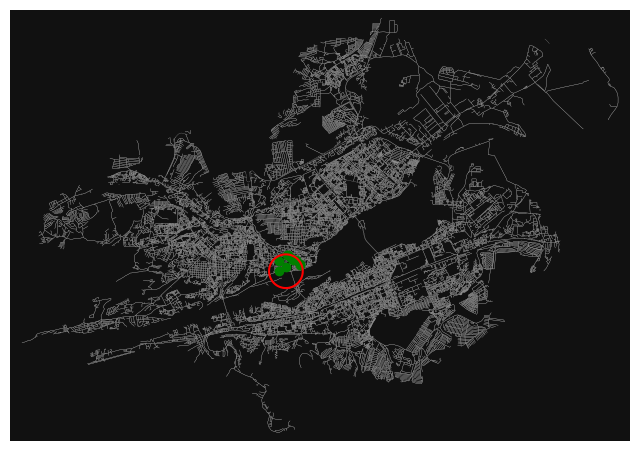

In [23]:
new_node = selector(None, dynamic_nodes)

fig, ax = ox.plot_graph(GP, show=False, close=False, node_size=0, edge_linewidth=0.2)
g_nodes.loc[[393823905]].geometry.buffer(DIST).boundary.plot(ax=ax, color='red')
g_nodes.loc[nodes_list].plot(ax=ax, color='green')
